<a href="https://colab.research.google.com/github/tiltfilibuster/deteccao-fraudes-transacao-bancaria/blob/main/modelos_detec%C3%A7ao_de_fraudes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecçao de fraudes em transaçoes

In [ ]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Problema de classificaçao desbalanceada

Fraudes sao raras o modelo pode ignorar a classe 1

In [ ]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


### Feature Engineering

In [ ]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])
df["scaled_time"] = scaler.fit_transform(df[["Time"]])

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(["Class", "Amount", "Time"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)


## Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state = 42)
lr_model.fit(X_train,y_train)

y_pred_lr = lr_model.predict(X_test)
y_probs_lr = lr_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



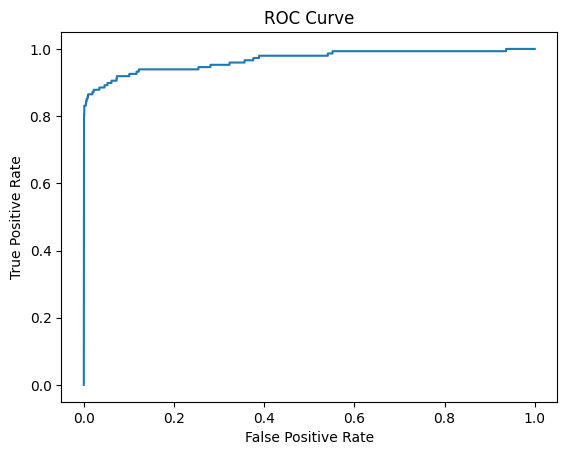

AUC: 0.9676923332852754


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr,tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

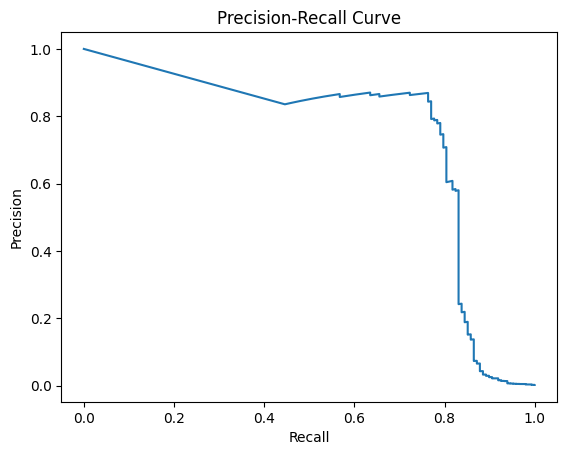

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall,precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## Balanceamento de dados

In [ ]:
#Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state = 42)

df_under = pd.concat([fraudes, normais])

In [ ]:
#Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X,y)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [ ]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     85295
           1       0.03      0.89      0.06       148

    accuracy                           0.95     85443
   macro avg       0.52      0.92      0.52     85443
weighted avg       1.00      0.95      0.97     85443



## Modelo XGboost
Corrigindo o desbalanceamento pelo calculo do peso ideal

In [ ]:
from xgboost import XGBClassifier

scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    scale_pos_weight = scale_weight,
    use_label_encoder = False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:20:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Importancia das variaveis

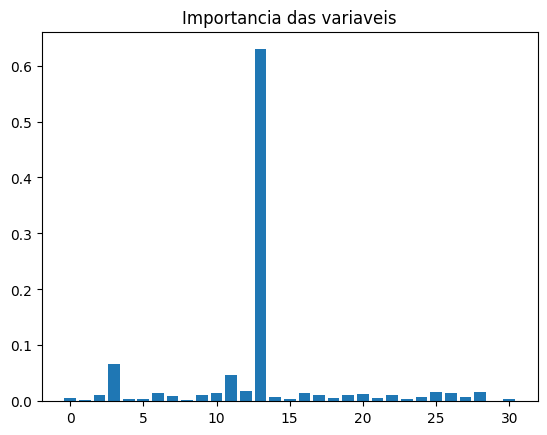

In [ ]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importancia das variaveis")
plt.show()


In [ ]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.90      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.95      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



## Ajuste de Hiperparametros

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3,5],
    "n_estimators": [50,10]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 5, 'n_estimators': 50}


In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.77      0.66      0.71       148

    accuracy                           1.00     85443
   macro avg       0.89      0.83      0.86     85443
weighted avg       1.00      1.00      1.00     85443

AUC-ROC: 0.8706649260198707


## Explicabilidade (SHAP)

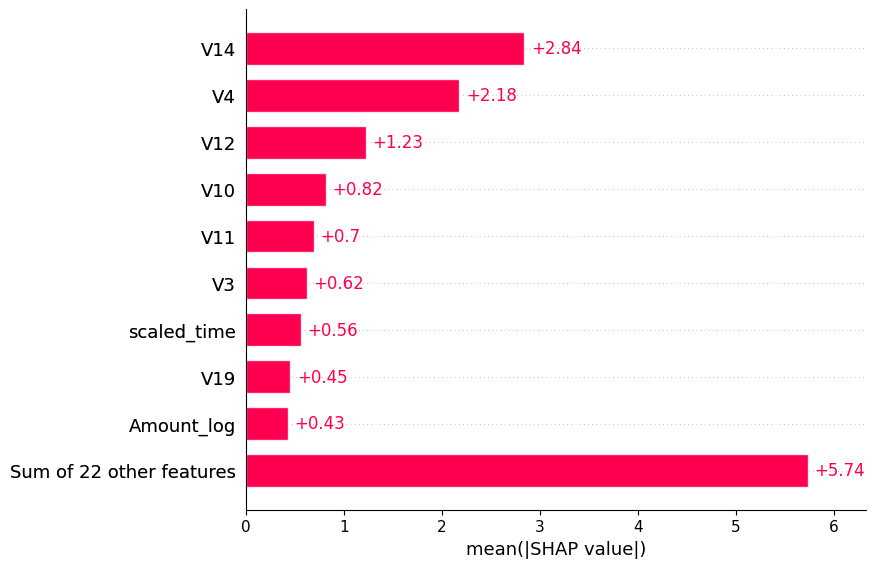

In [ ]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)